In [1]:
import h5py
import numpy as np
import os
import torch
import imageio
import json

import h5py
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

from robomimic.utils import file_utils as FileUtils
from robomimic.utils import obs_utils as ObsUtils
from robomimic.utils import env_utils as EnvUtils

from robomimic.envs.env_base import EnvBase
from robomimic.algo import RolloutPolicy
from copy import deepcopy

import h5py
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

/home/mzoellner/miniconda3/envs/guided-diffusion/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
CKPT_PATH = "../models/can/model_epoch_2000.pth"

device = "cuda" if torch.cuda.is_available() else "cpu"
# --- Load checkpoint dict (robomimic-style)
ckpt = torch.load(CKPT_PATH, map_location="cpu")
cfg = ckpt["config"]
cfg = json.loads(cfg)
cfg["observation"]["modalities"]
from robomimic.utils.file_utils import maybe_dict_from_checkpoint

# Replace with your actual model path
ckpt_dict = maybe_dict_from_checkpoint(CKPT_PATH)

# This will tell us the exact input dimension the policy network sees

# Important: init obs modalities exactly as training expected
ObsUtils.initialize_obs_utils_with_obs_specs(cfg["observation"]["modalities"])

frameenv, _ = FileUtils.env_from_checkpoint(
    ckpt_path=CKPT_PATH,
    render=True,
    render_offscreen=True,
)

env = frameenv

policy, _ = FileUtils.policy_from_checkpoint(
    ckpt_path=CKPT_PATH,
    device=device,
    verbose=True,
)


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_quat', 'robot0_eef_pos', 'robot0_gripper_qpos', 'object']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []


[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /home/mzoellner/Projects/research/guided-diffusion/robosuite/robosuite/scripts/setup_macros.py (macros.py:55)
[robosuite WARNING] Could not import robosuite_models. Some robots may not be available. If you want to use these robots, please install robosuite_models from source (https://github.com/ARISE-Initiative/robosuite_models) or through pip install. (__init__.py:30)


Created environment with name PickPlaceCan
Action size is 7
============= Loaded Config =============
{
    "algo_name": "diffusion_policy",
    "experiment": {
        "name": "can_mh_lowdim",
        "validate": false,
        "logging": {
            "terminal_output_to_txt": true,
            "log_tb": true,
            "log_wandb": true,
            "wandb_proj_name": "guided_diffusion"
        },
        "save": {
            "enabled": true,
            "every_n_seconds": null,
            "every_n_epochs": 50,
            "epochs": [],
            "on_best_validation": false,
            "on_best_rollout_return": false,
            "on_best_rollout_success_rate": true
        },
        "epoch_every_n_steps": 100,
        "validation_epoch_every_n_steps": 10,
        "env": null,
        "additional_envs": null,
        "render": false,
        "render_video": true,
        "keep_all_videos": true,
        "video_skip": 2,
        "rollout": {
            "enabled": true,
     

In [3]:
def quat_to_6d(q):
    """
    Converts quaternions (w, x, y, z) to 6D rotation representation.
    Output: [r1_x, r1_y, r1_z, r2_x, r2_y, r2_z]
    """
    w, x, y, z = q[..., 0], q[..., 1], q[..., 2], q[..., 3]

    # Full rotation matrix entries
    r00 = 1 - 2*(y**2 + z**2)
    r01 = 2*(x*y - w*z)
    r02 = 2*(x*z + w*y)

    r10 = 2*(x*y + w*z)
    r11 = 1 - 2*(x**2 + z**2)
    r12 = 2*(y*z - w*x)

    r20 = 2*(x*z - w*y)
    r21 = 2*(y*z + w*x)
    r22 = 1 - 2*(x**2 + y**2)

    # First two columns
    return np.stack([r00, r10, r20, r01, r11, r21], axis=-1)

In [4]:
# Abstraction: GT extractor + OBS extractor + looped comparison (+ 6D repr)
import robosuite.utils.transform_utils as T

def _find_env_with_attr(e, attr):
    cur = e
    for _ in range(20):
        if hasattr(cur, attr):
            return cur
        if hasattr(cur, "env"):
            cur = cur.env
        else:
            break
    raise RuntimeError(f"Could not find env with attribute '{attr}'")

def _latest_frame(x):
    a = np.asarray(x)
    return a[-1] if a.ndim > 1 else a

def _xyzw_to_wxyz(q):
    q = np.asarray(q)
    return np.concatenate([q[3:4], q[:3]], axis=0)

def get_ground_truth(e):
    # Simulator source for both absolute and reconstructed relative channels
    sim_env = _find_env_with_attr(e, "sim")
    rs_env = _find_env_with_attr(e, "robots")

    sim = sim_env.sim
    sim_model = sim.model if hasattr(sim, "model") else sim._model
    sim_data = sim.data if hasattr(sim, "data") else sim._data

    robot = rs_env.robots[0]
    arm = robot.arms[0]

    can_bid = sim_model.body_name2id("Can_main")
    eef_body_name = robot.robot_model.eef_name[arm]
    eef_bid = sim_model.body_name2id(eef_body_name)
    eef_sid = robot.eef_site_id[arm]

    # Absolute terms from sim
    q_can = T.convert_quat(sim_data.body_xquat[can_bid].copy(), to="xyzw")
    q_eef = T.convert_quat(sim_data.get_body_xquat(eef_body_name), to="xyzw")
    p_can = sim_data.body_xpos[can_bid].copy()
    p_eef = sim_data.site_xpos[eef_sid].copy()

    R_can = sim_data.body_xmat[can_bid].copy().reshape(3, 3)
    R_eef = sim_data.body_xmat[eef_bid].copy().reshape(3, 3)
    q_can_6d = np.concatenate([R_can[:, 0], R_can[:, 1]], axis=0)
    q_eef_6d = np.concatenate([R_eef[:, 0], R_eef[:, 1]], axis=0)

    # Relative terms reconstructed from absolute GT (robosuite transform math)
    world_pose_in_gripper = T.pose_inv(T.pose2mat((p_eef, q_eef)))
    obj_pose = T.pose2mat((p_can, q_can))
    rel_pose = T.pose_in_A_to_pose_in_B(obj_pose, world_pose_in_gripper)
    rel_p, rel_q = T.mat2pose(rel_pose)
    rel_q_6d = np.concatenate([rel_pose[:3, 0], rel_pose[:3, 1]], axis=0)

    return {
        "q_can": q_can,
        "q_eef": q_eef,
        "p_can": p_can,
        "p_eef": p_eef,
        "rel_p": rel_p,
        "rel_q": rel_q,
        "q_can_6d": q_can_6d,
        "q_eef_6d": q_eef_6d,
        "rel_q_6d": rel_q_6d,
    }

def get_obs_values(obs):
    obj = _latest_frame(obs["object"])
    q_eef = _latest_frame(obs["robot0_eef_quat"])
    p_eef = _latest_frame(obs["robot0_eef_pos"])

    q_can = obj[10:14]
    rel_q = obj[3:7]

    return {
        "q_can": q_can,
        "q_eef": q_eef,
        "p_can": obj[7:10],
        "p_eef": p_eef,
        "rel_p": obj[0:3],
        "rel_q": rel_q,
        "q_can_6d": quat_to_6d(_xyzw_to_wxyz(q_can)),
        "q_eef_6d": quat_to_6d(_xyzw_to_wxyz(q_eef)),
        "rel_q_6d": quat_to_6d(_xyzw_to_wxyz(rel_q)),
    }

def run_obs_vs_gt(e, steps=10, action_mode="zero"):
    state0 = e.get_state()
    obs = e.reset_to(state0)
    obs = e.get_observation()

    if action_mode == "policy":
        policy.start_episode()

    max_err = lambda x, y: float(np.max(np.abs(np.asarray(x) - np.asarray(y))))
    quat_err = lambda q1, q2: min(max_err(q1, q2), max_err(q1, -np.asarray(q2)))

    errs = {
        "q_can": [], "q_eef": [], "p_can": [], "p_eef": [],
        "rel_q": [], "rel_p": [],
        "q_can_6d": [], "q_eef_6d": [], "rel_q_6d": [],
    }

    for _ in range(steps):
        gt = get_ground_truth(e)
        ob = get_obs_values(obs)

        errs["q_can"].append(quat_err(ob["q_can"], gt["q_can"]))
        errs["q_eef"].append(quat_err(ob["q_eef"], gt["q_eef"]))
        errs["p_can"].append(max_err(ob["p_can"], gt["p_can"]))
        errs["p_eef"].append(max_err(ob["p_eef"], gt["p_eef"]))
        errs["rel_q"].append(quat_err(ob["rel_q"], gt["rel_q"]))
        errs["rel_p"].append(max_err(ob["rel_p"], gt["rel_p"]))
        errs["q_can_6d"].append(max_err(ob["q_can_6d"], gt["q_can_6d"]))
        errs["q_eef_6d"].append(max_err(ob["q_eef_6d"], gt["q_eef_6d"]))
        errs["rel_q_6d"].append(max_err(ob["rel_q_6d"], gt["rel_q_6d"]))

        # if action_mode == "policy":
        #     act = policy(ob=obs)
        # else:
        #     act = np.zeros(7)

        # obs, _, done, _ = e.step(act)
        # if done:
        #     break
        obs = e.get_observation()

    print(f"steps evaluated: {len(errs['q_can'])}")
    for k, v in errs.items():
        a = np.asarray(v[1:])
        print(f"{k:8s} max={float(np.max(a)):.3e} mean={float(np.mean(a)):.3e}")
    return errs

# Run with policy action
errs_abs = run_obs_vs_gt(env, steps=2, action_mode="zero")

steps evaluated: 2
q_can    max=0.000e+00 mean=0.000e+00
q_eef    max=0.000e+00 mean=0.000e+00
p_can    max=0.000e+00 mean=0.000e+00
p_eef    max=0.000e+00 mean=0.000e+00
rel_q    max=0.000e+00 mean=0.000e+00
rel_p    max=0.000e+00 mean=0.000e+00
q_can_6d max=1.110e-16 mean=1.110e-16
q_eef_6d max=6.661e-16 mean=6.661e-16
rel_q_6d max=5.238e-07 mean=5.238e-07


In [5]:
path = "../data/can/mh/low_dim_v15.hdf5"
path2 = "../data/can/ph/low_dim_v15.hdf5"
path3 = "../data/can/mg/low_dim_sparse_v15.hdf5"

DP_KEYS = ['object', 'robot0_eef_pos', 'robot0_eef_quat', 'robot0_gripper_qpos']

In [6]:
# loop through HDF keys of 'data'/'demo_0' and print them
with h5py.File(path, "r") as f: 
    demo_key = "demo_0"
    print(f"Keys in {demo_key}: {list(f['data'][demo_key].keys())}")

Keys in demo_0: ['actions', 'dones', 'next_obs', 'obs', 'rewards', 'states']


In [7]:
# Sanity check: next_obs[t] ~= obs[t+1] for demo_0 in `path`
with h5py.File(path, "r") as f:
    demo_key = "demo_0"
    demo = f["data"][demo_key]

    if "obs" not in demo or "next_obs" not in demo:
        raise KeyError("Expected both 'obs' and 'next_obs' groups under data/demo_0")

    obs_group = demo["obs"]
    next_obs_group = demo["next_obs"]

    shared_keys = sorted(set(obs_group.keys()).intersection(set(next_obs_group.keys())))
    if len(shared_keys) == 0:
        raise RuntimeError("No shared keys between obs and next_obs")

    print(f"demo: {demo_key}")
    print(f"shared keys: {shared_keys}")

    per_key = {}
    for k in shared_keys:
        obs_arr = obs_group[k][:]
        next_arr = next_obs_group[k][:]

        n = min(len(obs_arr), len(next_arr))
        if n < 2:
            print(f"{k:25s} skipped (length < 2)")
            continue

        # Compare next_obs[t] against obs[t+1], avoiding off-by-one at the end.
        diff = np.abs(next_arr[: n - 1] - obs_arr[1:n])
        per_key[k] = {
            "max": float(np.max(diff)),
            "mean": float(np.mean(diff)),
            "n_compared": int(n - 1),
        }

    print("\nnext_obs[t] vs obs[t+1] errors:")
    for k in sorted(per_key.keys()):
        d = per_key[k]
        print(f"{k:25s} max={d['max']:.3e} mean={d['mean']:.3e} n={d['n_compared']}")

demo: demo_0
shared keys: ['object', 'robot0_eef_pos', 'robot0_eef_quat', 'robot0_eef_quat_site', 'robot0_gripper_qpos', 'robot0_gripper_qvel', 'robot0_joint_pos', 'robot0_joint_pos_cos', 'robot0_joint_pos_sin', 'robot0_joint_vel']

next_obs[t] vs obs[t+1] errors:
object                    max=0.000e+00 mean=0.000e+00 n=117
robot0_eef_pos            max=0.000e+00 mean=0.000e+00 n=117
robot0_eef_quat           max=0.000e+00 mean=0.000e+00 n=117
robot0_eef_quat_site      max=0.000e+00 mean=0.000e+00 n=117
robot0_gripper_qpos       max=0.000e+00 mean=0.000e+00 n=117
robot0_gripper_qvel       max=0.000e+00 mean=0.000e+00 n=117
robot0_joint_pos          max=0.000e+00 mean=0.000e+00 n=117
robot0_joint_pos_cos      max=0.000e+00 mean=0.000e+00 n=117
robot0_joint_pos_sin      max=0.000e+00 mean=0.000e+00 n=117
robot0_joint_vel          max=0.000e+00 mean=0.000e+00 n=117


In [8]:
# Quick check: reset unwrapped env to demo_0 state and compare reset_to obs to dataset obs[0]
with h5py.File(path, "r") as f:
    demo_key = "demo_0"
    demo = f["data"][demo_key]
    ds_obs0 = {k: demo["obs"][k][0] for k in demo["obs"].keys()}
    ds_state0 = demo["states"][0]

base_env = env.env if hasattr(env, "env") else env
base_env.reset()
base_state = base_env.get_state()

# Use obs returned by reset_to directly (closer to dataset rollout semantics)
obs0_env = base_env.reset_to({"states": ds_state0, "model": base_state["model"]})

train_keys = [k for k in DP_KEYS if (k in ds_obs0 and k in obs0_env)]
print(f"demo: {demo_key}")
print("training keys:", train_keys)

print("\nobs_env(reset_to return) vs dataset obs[0] (max / mean abs diff):")
for k in train_keys:
    a = np.asarray(obs0_env[k])
    b = np.asarray(ds_obs0[k])
    diff = np.abs(a - b)
    print(f"{k:25s} max={float(np.max(diff)):.3e} mean={float(np.mean(diff)):.3e}")

demo: demo_0
training keys: ['object', 'robot0_eef_pos', 'robot0_eef_quat', 'robot0_gripper_qpos']

obs_env(reset_to return) vs dataset obs[0] (max / mean abs diff):
object                    max=1.192e-07 mean=8.914e-09
robot0_eef_pos            max=2.776e-17 mean=1.850e-17
robot0_eef_quat           max=2.358e-17 mean=7.196e-18
robot0_gripper_qpos       max=0.000e+00 mean=0.000e+00


In [9]:
# One-step transition check: env.step(dataset action[0]) vs dataset next_obs[0]
with h5py.File(path, "r") as f:
    demo_key = "demo_0"
    demo = f["data"][demo_key]

    ds_obs0 = {k: demo["obs"][k][0] for k in demo["obs"].keys()}
    ds_next0 = {k: demo["next_obs"][k][0] for k in demo["next_obs"].keys()}
    ds_state0 = demo["states"][0]
    ds_act0 = demo["actions"][0]

base_env = env.env if hasattr(env, "env") else env
base_env.reset()
base_state = base_env.get_state()

# Initialize to dataset state and take exactly the dataset action
_ = base_env.reset_to({"states": ds_state0, "model": base_state["model"]})
obs1_env, rew1, done1, info1 = base_env.step(ds_act0)

train_keys = [k for k in DP_KEYS if (k in obs1_env and k in ds_next0)]
print(f"demo: {demo_key}")
print("training keys:", train_keys)
print(f"reward={float(rew1):.6f} done={bool(done1)}")

print("\nobs_env(step after state0 + action0) vs dataset next_obs[0] (max / mean abs diff):")
for k in train_keys:
    a = np.asarray(obs1_env[k])
    b = np.asarray(ds_next0[k])
    diff = np.abs(a - b)
    print(f"{k:25s} max={float(np.max(diff)):.3e} mean={float(np.mean(diff)):.3e}")

demo: demo_0
training keys: ['object', 'robot0_eef_pos', 'robot0_eef_quat', 'robot0_gripper_qpos']
reward=0.000000 done=False

obs_env(step after state0 + action0) vs dataset next_obs[0] (max / mean abs diff):
object                    max=5.241e-04 mean=1.919e-04
robot0_eef_pos            max=4.131e-04 mean=3.093e-04
robot0_eef_quat           max=5.265e-04 mean=2.341e-04
robot0_gripper_qpos       max=4.559e-04 mean=4.245e-04


In [10]:
# Full-demo rollout check: step through all dataset actions and compare env obs to dataset next_obs
with h5py.File(path, "r") as f:
    demo_key = "demo_0"
    demo = f["data"][demo_key]

    ds_state0 = demo["states"][0]
    ds_actions = demo["actions"][:]
    ds_next = {k: demo["next_obs"][k][:] for k in demo["next_obs"].keys()}

base_env = env.env if hasattr(env, "env") else env
base_env.reset()
base_state = base_env.get_state()
_ = base_env.reset_to({"states": ds_state0, "model": base_state["model"]})

train_keys = [k for k in DP_KEYS if k in ds_next]
n_steps = min(len(ds_actions), min(len(ds_next[k]) for k in train_keys))

errs = {k: [] for k in train_keys}
steps_executed = 0

for t in range(n_steps):
    obs_t1, rew, done, info = base_env.step(ds_actions[t])
    steps_executed += 1

    for k in train_keys:
        env_val = np.asarray(obs_t1[k])
        ds_val = np.asarray(ds_next[k][t])
        errs[k].append(float(np.max(np.abs(env_val - ds_val))))

    if done:
        break

print(f"demo: {demo_key}")
print(f"steps compared: {steps_executed}")
print("\npost-step env obs vs dataset next_obs[t] (max abs error):")

overall_worst_key = None
overall_worst_step = -1
overall_worst_val = -1.0
threshold = 5e-2

for k in train_keys:
    a = np.asarray(errs[k])
    worst_i = int(np.argmax(a))
    worst_v = float(a[worst_i])
    mean_v = float(np.mean(a))

    bad_idx = np.where(a > threshold)[0]
    bad_vals = a[bad_idx]
    bad_pairs = [f"({int(i)}, {float(v):.4f})" for i, v in zip(bad_idx, bad_vals)]

    print(f"{k:25s} max={worst_v:.3e} mean={mean_v:.3e} step={worst_i}")
    print(f"  > {threshold:.0e}: count={len(bad_pairs)} values={bad_pairs}")

    if worst_v > overall_worst_val:
        overall_worst_key = k
        overall_worst_step = worst_i
        overall_worst_val = worst_v

print(f"\nOVERALL WORST: key={overall_worst_key} step={overall_worst_step} err={overall_worst_val:.3e}")

demo: demo_0
steps compared: 118

post-step env obs vs dataset next_obs[t] (max abs error):
object                    max=1.926e+00 mean=3.653e-02 step=114
  > 5e-02: count=6 values=['(57, 1.9150)', '(112, 0.0543)', '(113, 0.0781)', '(114, 1.9260)', '(115, 0.0699)', '(117, 0.0646)']
robot0_eef_pos            max=2.051e-03 mean=5.824e-04 step=117
  > 5e-02: count=0 values=[]
robot0_eef_quat           max=2.588e-03 mean=3.979e-04 step=117
  > 5e-02: count=0 values=[]
robot0_gripper_qpos       max=4.130e-03 mean=5.160e-04 step=112
  > 5e-02: count=0 values=[]

OVERALL WORST: key=object step=114 err=1.926e+00


In [11]:
# Final sanity sweep: run full-demo replay check for every demo in path and path2.
# For each demo, report how many (step, key) errors exceed threshold,
# and print a compact list of offending (error, key, step) tuples.

def _unwrap_env(e):
    return e.env if hasattr(e, "env") else e

def _demo_threshold_report(dataset_path, threshold=5e-2, max_pairs_to_print=None):
    base_env = _unwrap_env(env)

    print("=" * 100)
    print(f"DATASET: {dataset_path}")

    with h5py.File(dataset_path, "r") as f:
        demo_keys = sorted(list(f["data"].keys()))
        print(f"num demos: {len(demo_keys)} | threshold: {threshold:.0e}")

        for demo_key in demo_keys:
            demo = f["data"][demo_key]

            ds_state0 = demo["states"][0]
            ds_actions = demo["actions"][:]
            ds_next = {k: demo["next_obs"][k][:] for k in demo["next_obs"].keys()}

            train_keys = [k for k in DP_KEYS if k in ds_next]
            if len(train_keys) == 0:
                print(f"{demo_key:20s} EXCEED=0 steps=0 bad=[] (no training keys present)")
                continue

            n_steps = min(len(ds_actions), min(len(ds_next[k]) for k in train_keys))

            # Reset simulator to demo initial state before replaying actions.
            base_env.reset()
            base_state = base_env.get_state()
            _ = base_env.reset_to({"states": ds_state0, "model": base_state["model"]})

            bad = []
            steps_executed = 0

            for t in range(n_steps):
                obs_t1, _, done, _ = base_env.step(ds_actions[t])
                steps_executed += 1

                for k in train_keys:
                    env_val = np.asarray(obs_t1[k])
                    ds_val = np.asarray(ds_next[k][t])
                    err = float(np.max(np.abs(env_val - ds_val)))
                    if err > threshold:
                        bad.append((err, k, t))

                if done:
                    break

            # Largest first to quickly spot catastrophic demos.
            bad_sorted = sorted(bad, key=lambda x: x[0], reverse=True)
            if max_pairs_to_print is not None:
                bad_print = bad_sorted[:max_pairs_to_print]
            else:
                bad_print = bad_sorted

            bad_print_fmt = [(round(v, 4), k, int(t)) for (v, k, t) in bad_print]
            per_key_max = {
                k: (max([v for (v, kk, _) in bad_sorted if kk == k]) if any(kk == k for (_, kk, _) in bad_sorted) else 0.0)
                for k in train_keys
            }

            print(f"{demo_key:20s} EXCEED={len(bad_sorted):4d} steps={steps_executed:4d}")
            print(f"  key_max={{{', '.join([f'{k}: {per_key_max[k]:.4f}' for k in train_keys])}}}")
            print(f"  bad={bad_print_fmt}")

# Run both datasets. Set max_pairs_to_print to an int (e.g., 30) if output is too large.
threshold = 5e-2
_demo_threshold_report(path, threshold=threshold, max_pairs_to_print=None)
_demo_threshold_report(path2, threshold=threshold, max_pairs_to_print=None)

DATASET: ../data/can/mh/low_dim_v15.hdf5
num demos: 300 | threshold: 5e-02
demo_0               EXCEED=   6 steps= 118
  key_max={object: 1.9260, robot0_eef_pos: 0.0000, robot0_eef_quat: 0.0000, robot0_gripper_qpos: 0.0000}
  bad=[(1.926, 'object', 114), (1.915, 'object', 57), (0.0781, 'object', 113), (0.0699, 'object', 115), (0.0646, 'object', 117), (0.0543, 'object', 112)]
demo_1               EXCEED=  20 steps= 118
  key_max={object: 1.9007, robot0_eef_pos: 0.0000, robot0_eef_quat: 0.0000, robot0_gripper_qpos: 0.0000}
  bad=[(1.9007, 'object', 75), (1.8998, 'object', 74), (1.8989, 'object', 73), (1.8985, 'object', 117), (1.8977, 'object', 72), (1.8966, 'object', 71), (1.8953, 'object', 70), (1.894, 'object', 69), (1.893, 'object', 68), (1.8928, 'object', 60), (1.8926, 'object', 61), (1.8924, 'object', 62), (1.8924, 'object', 67), (1.8924, 'object', 63), (1.8919, 'object', 66), (0.1405, 'object', 115), (0.1289, 'object', 114), (0.0728, 'object', 113), (0.0716, 'object', 112), (0.0704

KeyboardInterrupt: 

 Demos with EXCEED > 20 (from demo_summary)

Total demos over threshold: **39**

 ../data/can/mh/low_dim_v15.hdf5 (34)

demo_117 - 23  
demo_131 - 32  
demo_132 - 76  
demo_143 - 73  
demo_145 - 78  
demo_150 - 100  
demo_151 - 27  
demo_183 - 127  
demo_201 - 331  
demo_202 - 32  
demo_203 - 104  
demo_206 - 192  
demo_208 - 497  
demo_209 - 558  
demo_210 - 23  
demo_214 - 91  
demo_220 - 212  
demo_223 - 64  
demo_226 - 95  
demo_228 - 235  
demo_229 - 409  
demo_231 - 85  
demo_242 - 41  
demo_244 - 321  
demo_245 - 404  
demo_248 - 561  
demo_273 - 54  
demo_279 - 25  
demo_291 - 22  
demo_62 - 186  
demo_64 - 1757  
demo_69 - 310  
demo_86 - 284  
demo_87 - 24

 ../data/can/ph/low_dim_v15.hdf5 (5)

demo_112 - 33  
demo_176 - 33  
demo_19 - 34  
demo_28 - 38  
demo_95 - 82

demo_199 gpos shape: (96, 2)
gpos min: [ 0.020833   -0.03962564]
gpos max: [ 0.03968572 -0.020833  ]
gpos[0]: [ 0.020833 -0.020833]
gpos[-1]: [ 0.0388991  -0.03822067]

action[6] (gripper command) shape: (96,)
action[6] min: -1.0
action[6] max: 1.0


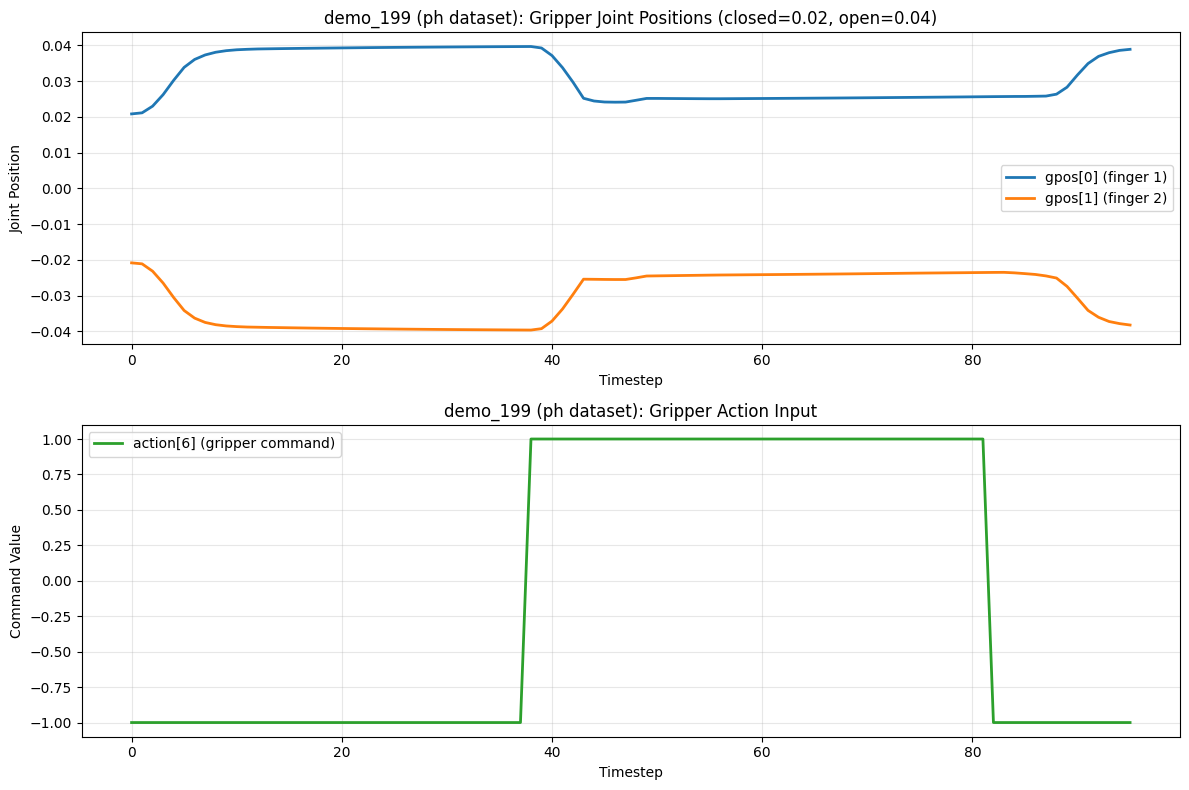


Observation keys in demo_199: ['object', 'robot0_eef_pos', 'robot0_eef_quat', 'robot0_eef_quat_site', 'robot0_gripper_qpos', 'robot0_gripper_qvel', 'robot0_joint_pos', 'robot0_joint_pos_cos', 'robot0_joint_pos_sin', 'robot0_joint_vel']


In [12]:

# Load demo_199 from ph dataset and plot gpos trajectory
with h5py.File(path2, "r") as f:
    demo = f["data"]["demo_199"]
    gpos = demo["obs"]["robot0_gripper_qpos"][:]  # shape [T, 2]
    actions = demo["actions"][:]  # shape [T, 7]
    gripper_action = actions[:, 6]  # gripper command
    
    print(f"demo_199 gpos shape: {gpos.shape}")
    print(f"gpos min: {gpos.min(axis=0)}")
    print(f"gpos max: {gpos.max(axis=0)}")
    print(f"gpos[0]: {gpos[0]}")
    print(f"gpos[-1]: {gpos[-1]}")
    print(f"\naction[6] (gripper command) shape: {gripper_action.shape}")
    print(f"action[6] min: {gripper_action.min()}")
    print(f"action[6] max: {gripper_action.max()}")
    
    # Plot both gripper joint positions and gripper command
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    # Top: gpos joint positions
    ax1.plot(gpos[:, 0], label='gpos[0] (finger 1)', linewidth=2, color='C0')
    ax1.plot(gpos[:, 1], label='gpos[1] (finger 2)', linewidth=2, color='C1')
    ax1.set_xlabel('Timestep')
    ax1.set_ylabel('Joint Position')
    ax1.set_title('demo_199 (ph dataset): Gripper Joint Positions (closed=0.02, open=0.04)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Bottom: gripper command
    ax2.plot(gripper_action, label='action[6] (gripper command)', linewidth=2, color='C2')
    ax2.set_xlabel('Timestep')
    ax2.set_ylabel('Command Value')
    ax2.set_title('demo_199 (ph dataset): Gripper Action Input')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nObservation keys in demo_199: {sorted(list(demo['obs'].keys()))}")